In [11]:
# !pip install --upgrade numpy
# !pip install pyriemann
# !pip install moabb

## [pyRiemann](https://pyriemann.readthedocs.io/en/latest/index.html)
Готовая бибиотека, совместимая с sklearn для применения римановой геометрии.

### [Датасет BNCI2014-002](https://moabb.neurotechx.com/docs/generated/moabb.datasets.BNCI2014_002.html)
Содержит записи электроэнцефалограммы (ЭЭГ) от 14 здоровых испытуемых, выполненные в парадигме воображаемого движения. Записи проводились с использованием 15 электродов по системе 10–20 (включая референс). Частота дискретизации 250 Гц.

В бинарной постановке задачи рассматриваются только два класса: нога (класс 1), правая рука (класс 0).

### Необходимые библиотеки

In [1]:
from moabb.datasets import BNCI2014_002
from moabb.paradigms import MotorImagery
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from pyriemann.tangentspace import TangentSpace
from pyriemann.estimation import Shrinkage
from pyriemann.estimation import Covariances

import warnings
warnings.simplefilter("ignore")

### Загрузка датасета

In [4]:
dataset = BNCI2014_002()
subject = 2
paradigm = MotorImagery(n_classes=2, fmin=8, fmax=32)

X, y, metadata = paradigm.get_data(dataset, subjects=[subject])

y = np.array([1 if label == 'right_hand' else 0 for label in y])

print(f"Objects shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of objects of class 1 (right_hand): {np.sum(y)}")

Objects shape: (160, 15, 2561)
Labels shape: (160,)
Number of objects of class 1 (right_hand): 80


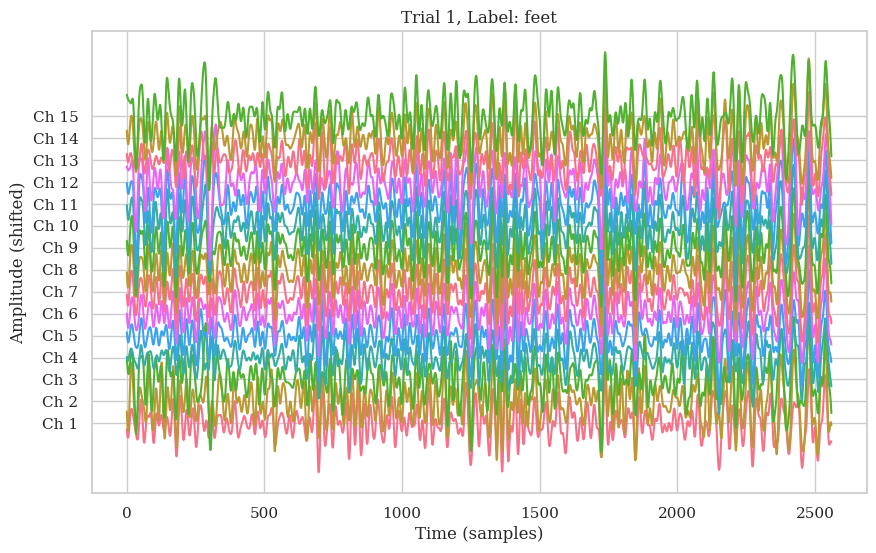

In [3]:
trial_data = X[0]  # Форма: (n_channels, n_times)
label = "right_hand" if y[0] == 1 else "feet"

plt.figure(figsize=(10, 6))
plt.title(f"Trial 1, Label: {label}")

for i in range(trial_data.shape[0]):
    plt.plot(trial_data[i, :] + i * 5, label=f"Channel {i+1}")

plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (shifted)")
plt.yticks(np.arange(trial_data.shape[0]) * 5, [f"Ch {i+1}" for i in range(trial_data.shape[0])])
plt.grid(True)
plt.show()

### Обучение и тестирование классификатора

#### Без использования римановой геометрии

In [5]:
class UpperTriangularVectorization(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        n_matrices, n_channels, _ = X.shape
        triu_indices = np.triu_indices(n_channels)
        return X[:, triu_indices[0], triu_indices[1]]

pipeline = make_pipeline(
    Covariances(estimator='scm'),       # 1. Оценка ковариационных матриц
    UpperTriangularVectorization(),     # 2. Выпрямление в вектор
    LogisticRegression(                 # 3. Классификация с помощью логистической регрессии
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
)

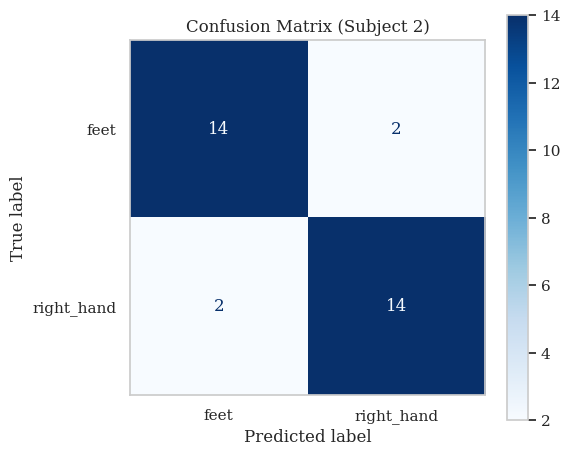


Точность на тестовой выборке (Пациент 2): 0.875


In [6]:
# -----------------------------
# Разделение на train / test и обучение
# -----------------------------

# Разделяем данные (80% — обучение, 20% — тест)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
class_names = ['feet', 'right_hand']

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f'Confusion Matrix (Subject {subject})')
ax.grid(False)
plt.tight_layout()
plt.show()

from sklearn.metrics import accuracy_score
test_acc = accuracy_score(y_test, y_pred)
print(f"\nТочность на тестовой выборке (Пациент {subject}): {test_acc:.3f}")

In [7]:
# -----------------------------
# Кросс-валидация
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"\nAccuracy (LogisticRegression) по паценту {subject}: {scores.mean():.3f} +- {scores.std():.3f}")


Accuracy (LogisticRegression) по паценту 2: 0.781 +- 0.077


#### Учтем геометрию матриц с помощью проекции на касательное пространство

In [8]:
pipeline = make_pipeline(
    Covariances(estimator='scm'),       # 1. Оценка ковариационных матриц
    Shrinkage(shrinkage=1e-4),          # 2. Регуляризация ковариационных матриц
    TangentSpace(metric='riemann'),     # 3. Проекция в касательное пространство
    LogisticRegression(                 # 4. Классификация с помощью логистической регрессии
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
)

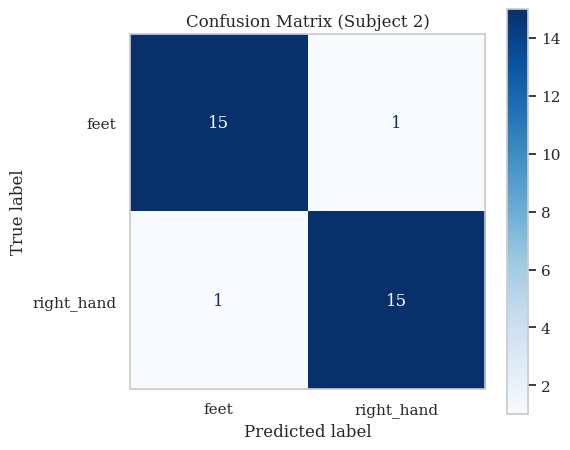


Точность на тестовой выборке (Пациент 2): 0.938


In [9]:
# -----------------------------
# Разделение на train / test и обучение
# -----------------------------

# Разделяем данные (80% — обучение, 20% — тест)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
class_names = ['feet', 'right_hand']

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f'Confusion Matrix (Subject {subject})')
ax.grid(False)
plt.tight_layout()
plt.show()

from sklearn.metrics import accuracy_score
test_acc = accuracy_score(y_test, y_pred)
print(f"\nТочность на тестовой выборке (Пациент {subject}): {test_acc:.3f}")

In [10]:
# -----------------------------
# Кросс-валидация
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"\nAccuracy (LogisticRegression) по паценту {subject}: {scores.mean():.3f} +- {scores.std():.3f}")


Accuracy (LogisticRegression) по паценту 2: 0.844 +- 0.081


Ура, выигрыш сразу на 10%